In [1]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline

In [4]:
from sklearn.datasets import load_iris
iris = load_iris()

In [8]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [9]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)

In [11]:
df=df[['petal length (cm)','petal width (cm)']]

In [12]:
print(df.head())

   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2


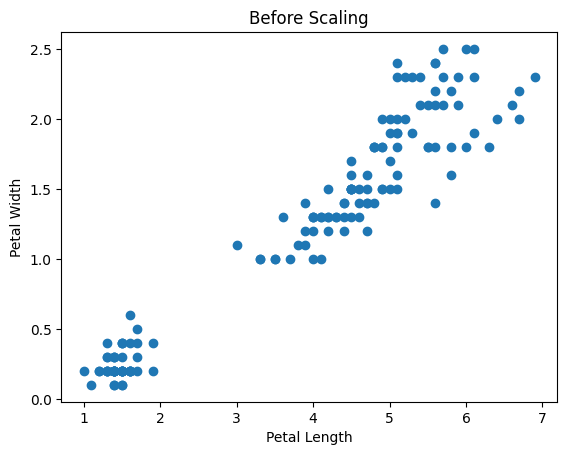

In [13]:
plt.scatter(df['petal length (cm)'],df['petal width (cm)'])
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Before Scaling')
plt.show()

In [14]:
scaler=MinMaxScaler()
df_scaled=scaler.fit_transform(df)
df_scaled=pd.DataFrame(df_scaled,columns=df.columns)
df_scaled.head()

,petal length (cm),petal width (cm)
0,0.067797,0.041667
1,0.067797,0.041667
2,0.050847,0.041667
3,0.084746,0.041667
4,0.067797,0.041667


In [15]:
sse=[]
k_rng=range(1,10)
for k in k_rng:
  km=KMeans(n_clusters=k)
  km.fit(df_scaled)
  sse.append(km.inertia_)

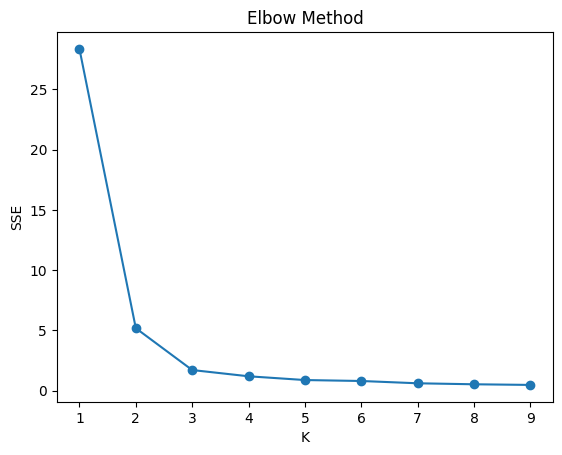

In [16]:
plt.plot(k_rng,sse,marker='o')
plt.xlabel('K')
plt.ylabel('SSE')
plt.title('Elbow Method')
plt.show()

In [17]:
km=KMeans(n_clusters=3,random_state=42)
y_pred=km.fit_predict(df_scaled)
df_scaled['cluster']=y_pred
print(df_scaled.head())

   petal length (cm)  petal width (cm)  cluster
0           0.067797          0.041667        1
1           0.067797          0.041667        1
2           0.050847          0.041667        1
3           0.084746          0.041667        1
4           0.067797          0.041667        1


In [18]:
df1=df_scaled[df_scaled.cluster==0]
df2=df_scaled[df_scaled.cluster==1]
df3=df_scaled[df_scaled.cluster==2]

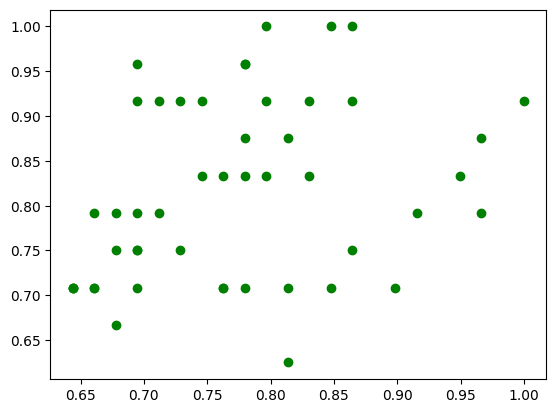

In [20]:
plt.scatter(df1['petal length (cm)'],df1['petal width (cm)'],color='green',label='Cluster 1')

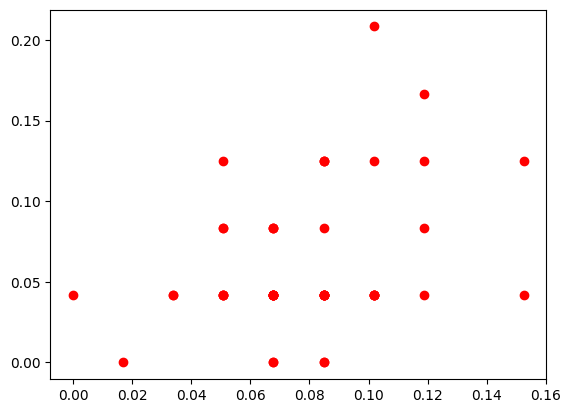

In [22]:
plt.scatter(df2['petal length (cm)'],df2['petal width (cm)'],color='red',label='Cluster 2')

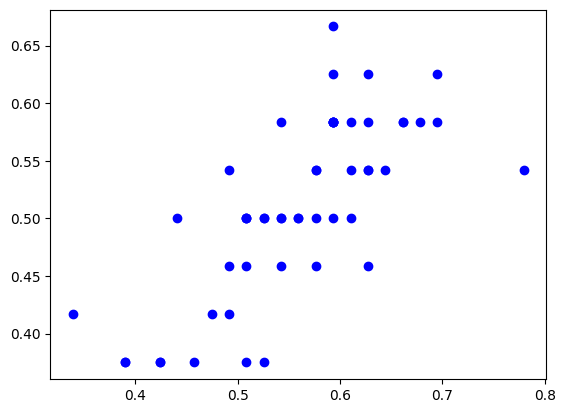

In [23]:
plt.scatter(df3['petal length (cm)'],df3['petal width (cm)'],color='blue',label='Cluster 3')

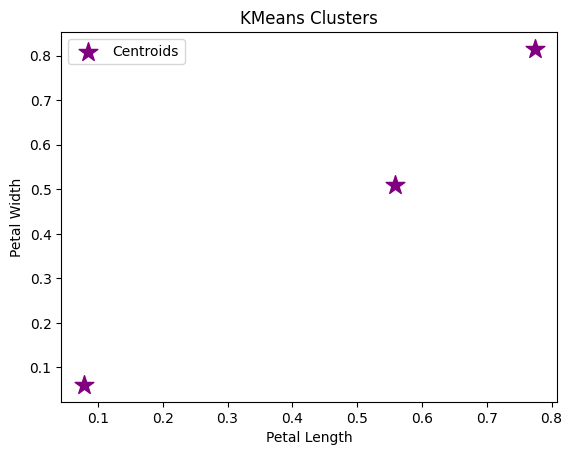

In [26]:
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',s=200,label='Centroids')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('KMeans Clusters')
plt.legend()
plt.show()

In [27]:
import joblib

In [28]:
joblib.dump(km,'iris_kmeans_model.pkl')
print("Model saved successfully!")

Model saved successfully!
